# Part 1. Equation of a Slime

How many late days are you using for this assignment? 0

In [208]:
# Imports section 
import numpy as np
import pandas as pd
import sklearn.model_selection
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

## 1. Loading the dataset

In [209]:
# Using pandas load the dataset
# Output the first 15 rows of the data
# Display a summary of the table information (number of datapoints, etc.)
main_data = pd.read_csv("science_data_large.csv")
display(main_data.head(15))
main_data.info()
main_data.describe()

,Temperature °C,Mols KCL,Size nm^3
0,469,647,6.244743e+05
1,403,694,5.779610e+05
2,302,975,6.196847e+05
3,779,916,1.460449e+06
4,901,18,4.325726e+04
5,545,637,7.124634e+05
6,660,519,7.006960e+05
7,143,869,2.718260e+05
8,89,461,8.919803e+04
9,294,776,4.770210e+05


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature °C  1000 non-null   int64  
 1   Mols KCL        1000 non-null   int64  
 2   Size nm^3       1000 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 23.6 KB


,Temperature °C,Mols KCL,Size nm^3
count,1000.000000,1000.000000,1.000000e+03
mean,500.500000,471.530000,5.086111e+05
std,288.819436,288.482872,4.474838e+05
min,1.000000,1.000000,1.611429e+01
25%,250.750000,226.750000,1.298267e+05
50%,500.500000,459.500000,3.827182e+05
75%,750.250000,710.250000,7.603211e+05
max,1000.000000,1000.000000,1.972127e+06


## 2. Splitting the dataset

In [210]:
# Take the pandas dataset and split it into our features (X) and label (y)

X = main_data[["Temperature °C", "Mols KCL"]]
y = main_data["Size nm^3"]

# Use sklearn to split the features and labels into a training/test set. (90% train, 10% test)
# For grading consistency use random_state=42 

train_X, test_X = sklearn.model_selection.train_test_split(X, train_size=0.9, random_state=42)
train_y, test_y = sklearn.model_selection.train_test_split(y, train_size=0.9, random_state=42)

## 3. Perform a Linear Regression

In [211]:
# Use sklearn to train a model on the training set

lin_model = LinearRegression()
lin_model.fit(train_X, train_y)

# Create a sample datapoint and predict the output of that sample with the trained model

sample = pd.DataFrame({"Temperature °C": [500,], "Mols KCL": [471,]})
prediction = lin_model.predict(sample)
print("Prediction:", prediction)

# Report the score for that model using the default score function property of the SKLearn model, in your own words (markdown, not code) explain what the score means

score = lin_model.score(test_X, test_y)
print("Score:", score)

# Extract the coefficients and intercept from the model and write an equation for your h(x) using LaTeX

display(lin_model.coef_)
display(lin_model.intercept_)

Prediction: [510081.10341736]
Score: 0.8552472077276096


array([ 866.14641337, 1032.69506649])

-409391.4795834081

### Write the linear equation of a slime: (example equation: $E = mc^2$)

$S = 866.15\cdot T + 1032.7\cdot K -4.0939\text{e}5$,

where S is the size of the blob in nanometers cubed, T is the temperature in degrees Celsius, and K is the amount of potassium chloride in moles. 

### Report on score and explain meaning:

The score, for which sklearn uses the coefficient of determination (also called $R^2$) by default, was 0.85525. Intuitively, this means about 85.525\% of the variation in the slime sizes was explained by the regression on the temperature and amount of potassium chloride, in the test set. 

## 4. Use Cross Validation

In [212]:
# Use the cross_val_score function to repeat your experiment across many shuffles of the data
# For grading consistency use n_splits=5 and random_state=42

cross_val_lin_model = LinearRegression()

cv = sklearn.model_selection.KFold(n_splits=5, random_state=42, shuffle=True)

cvs = sklearn.model_selection.cross_val_score(cross_val_lin_model, X, y, cv=cv)
display(cvs)
print("Mean score:", cvs.mean())

# Report on their finding and their significance

array([0.86151889, 0.82742341, 0.87195173, 0.88166206, 0.85609101])

Mean score: 0.8597294202684646


### Write findings here:

After recording the scores (coefficient of determination of the test data) on 5 shuffle splits of the data, we get a mean score of about 86% (0.0.85973), meaning an average of about 86% of the variation of slime size in each test set was explained by the regression on the train set. At a glance, it also looks pretty consistent, with a max of about 88.1% and min of about 82.7%. 

## 5. Using Polynomial Regression

In [213]:
# Using the PolynomialFeatures library perform another regression on an augmented dataset of degree 2
# Perform k-fold cross validation (as above)

poly = PolynomialFeatures(degree=2)
X2 = poly.fit_transform(X)

train_X2, test_X2 = sklearn.model_selection.train_test_split(X2, train_size=0.9, random_state=42)

lin_model_on_poly = LinearRegression(fit_intercept=False)
lin_model_on_poly.fit(train_X2, train_y)

cv = sklearn.model_selection.KFold(n_splits=5, random_state=42, shuffle=True)
cvs = sklearn.model_selection.cross_val_score(lin_model_on_poly, train_X2, train_y, cv=cv)

print(lin_model_on_poly.coef_)
print(cvs)
print("Names of features:", poly.get_feature_names_out())

# Report on the metrics and output the resultant equation as you did in Part 3.

[ 2.04806458e-05  1.20000000e+01 -1.27200067e-07  1.26469955e-11
  2.00000000e+00  2.85714287e-02]
[1. 1. 1. 1. 1.]
Names of features: ['1' 'Temperature °C' 'Mols KCL' 'Temperature °C^2'
 'Temperature °C Mols KCL' 'Mols KCL^2']


### Write the polynomial equation of a slime: (example equation: $E = mc^2$)

$S = 2.0481\cdot10^{-5} + 12\cdot T - 1.2720\cdot10^{-7}\cdot K + 1.2647\cdot 10^{-11}\cdot T^2 + 2\cdot TK + 2.8571\cdot 10^{-2}\cdot K^2$

where S is the size of the blob in nanometers cubed, T is the temperature in degrees Celsius, and K is the amount of potassium chloride in moles. 

### Report on the score and interpret:

The score with cross validation is always 1, meaning the polynomial model with degree 2 perfectly predicts all outputs up to a rounding error, even for the test data it has never seen before.

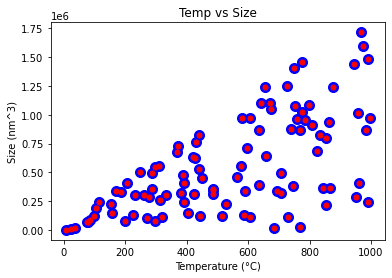

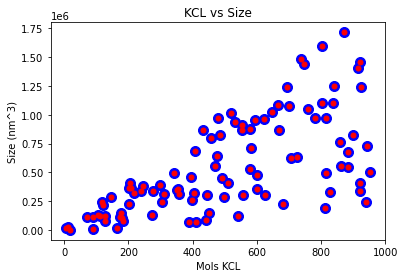

In [214]:
# Visualization of the points and the predictions

plt.scatter(test_X["Temperature °C"], test_y, s=100, c="blue")
plt.scatter(test_X["Temperature °C"], lin_model_on_poly.predict(test_X2), s=25, c="red")
plt.xlabel("Temperature (°C)")
plt.ylabel("Size (nm^3)")
plt.title("Temp vs Size")
plt.show()

plt.scatter(test_X["Mols KCL"], test_y, s=100, c="blue")
plt.scatter(test_X["Mols KCL"], lin_model_on_poly.predict(test_X2), s=25, c="red")
plt.xlabel("Mols KCL")
plt.ylabel("Size (nm^3)")
plt.title("KCL vs Size")
plt.show()

# Part 2. Chronic Kidney Disease Prediction via Classification

Create code and markdown cells as needed to perform classification and report on your results

In [215]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.neural_network import MLPClassifier

In [216]:
# Load the dataset. Then train and evaluate the classification models.

ckd_data = pd.read_csv("ckd_feature_subset.csv")

X = ckd_data.drop('Target_ckd', axis=1)
y = ckd_data['Target_ckd']
cv = sklearn.model_selection.KFold(n_splits=5, random_state=42, shuffle=True)

In [217]:
log_reg = LogisticRegression()
cvs_log_reg = sklearn.model_selection.cross_val_score(log_reg, X, y, cv=cv, scoring='accuracy')
print(cvs_log_reg)
print("Logistic regression mean scores:", cvs_log_reg.mean())
print("Standard deviation of scores:", cvs_log_reg.std())

[0.80645161 0.93548387 0.77419355 0.83333333 0.93333333]
Logistic regression mean scores: 0.8565591397849461
Standard deviation of scores: 0.0662686697755876


In [218]:
svc = SVC()
cvs_svc = sklearn.model_selection.cross_val_score(svc, X, y, cv=cv, scoring='accuracy')
print(cvs_svc)
print("Support Vector mean scores:", cvs_svc.mean())
print("Standard deviation of scores:", cvs_svc.std())

[0.90322581 1.         0.87096774 0.9        0.96666667]
Support Vector mean scores: 0.9281720430107526
Standard deviation of scores: 0.04760126519964333


In [219]:
knn = KNeighborsClassifier()
cvs_knn = sklearn.model_selection.cross_val_score(knn, X, y, cv=cv, scoring='accuracy')
print(cvs_knn)
print("K Nearest Neighbors mean scores:", cvs_knn.mean())
print("Standard deviation of scores:", cvs_knn.std())

[0.93548387 1.         0.87096774 0.86666667 0.96666667]
K Nearest Neighbors mean scores: 0.9279569892473118
Standard deviation of scores: 0.05243961560473918


In [220]:
mlp = MLPClassifier(random_state=42, max_iter=2000)
cvs_mlp = sklearn.model_selection.cross_val_score(mlp, X, y, cv=cv, scoring='accuracy')
print(cvs_mlp)
print("Multilayer Perceptron mean scores:", cvs_mlp.mean())
print("Standard deviation of scores:", cvs_mlp.std())

[0.90322581 0.96774194 0.87096774 0.96666667 0.96666667]
Multilayer Perceptron mean scores: 0.9350537634408603
Standard deviation of scores: 0.040465552982107675


In [221]:
results = {}
types = ["Logistic Regression", "Support Vector Machine", "K Nearest Neighbors", "Multilayer Perceptron"]
cvss = [cvs_log_reg, cvs_svc, cvs_knn, cvs_mlp]
for i in range(4):
    results[types[i]] = {"Mean Score": cvss[i].mean(), "Standard Dev Score": cvss[i].std()}

result_df = pd.DataFrame(results).T
display(result_df)

,Mean Score,Standard Dev Score
Logistic Regression,0.856559,0.066269
Support Vector Machine,0.928172,0.047601
K Nearest Neighbors,0.927957,0.052440
Multilayer Perceptron,0.935054,0.040466


## Results and Conclusion for Classification Experiments

| Model                     | Mean Score | Standard Deviation Score |
|---------------------------|------------|---------------------------|
| Logistic Regression        | 0.85656   | 0.06627                  |
| Support Vector Machine     | 0.92817   | 0.04760                  |
| K Nearest Neighbors        | 0.92796   | 0.05244                  |
| Multilayer Perceptron     | 0.93505   | 0.04047                  |

The most consistent, and best mean score model, was the multilayer perceptron, which correctly predicted the target_ckd column with 93.505% accuracy over 5 runs. This makes sense, because it is also the model which took by far the longest time to train (over 1 second, with the other models taking less than 100 milliseconds). The support vector machine and k-nearest-neighbors models did similarly well, and the logistic regression only had a 85.656% accuracy over 5 runs.

In [222]:
# Experiments with Neural Network.
results = {}
experiments = ["Identity 10", "ReLU 10", "ReLU 10,10", "ReLU 20", "ReLU 20 max 500 iter", "Identity 20"]

neural_networks = [
    MLPClassifier(hidden_layer_sizes=(10,), activation="identity", max_iter=2000, random_state=42),
    MLPClassifier(hidden_layer_sizes=(10,), activation="relu", max_iter=2000, random_state=42),
    MLPClassifier(hidden_layer_sizes=(10,10), activation="relu", max_iter=2000, random_state=42),
    MLPClassifier(hidden_layer_sizes=(20,), activation="relu", max_iter=2000, random_state=42),
    MLPClassifier(hidden_layer_sizes=(20,), activation="relu", max_iter=500, random_state=42),
    MLPClassifier(hidden_layer_sizes=(20,), activation="identity", max_iter=2000, random_state=42)
]

for i, network in enumerate(neural_networks):
    cvs = sklearn.model_selection.cross_val_score(network, X, y, cv=cv, scoring="accuracy")
    results[experiments[i]] = {"Mean Score": cvs.mean(), "Standard Deviation Score": cvs.std()}
result_df = pd.DataFrame(results).T
display(result_df)

/Users/<redacted>/miniforge3/envs/mlp/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/<redacted>/miniforge3/envs/mlp/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/<redacted>/miniforge3/envs/mlp/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/<redacted>/miniforge3/envs/mlp/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged ye

,Mean Score,Standard Deviation Score
Identity 10,0.928387,0.055305
ReLU 10,0.921720,0.056307
"ReLU 10,10",0.935054,0.040466
ReLU 20,0.941505,0.037327
ReLU 20 max 500 iter,0.876129,0.068623
Identity 20,0.928387,0.047183


## Results and Conclusion for Neural Network Experiments

| Model                          | Mean Score | Standard Deviation Score |
|--------------------------------|------------|---------------------------|
| Identity 10                    | 0.92839   | 0.05531                  |
| ReLU 10                        | 0.92172   | 0.05631                  |
| ReLU 10,10                     | 0.93505   | 0.04047                  |
| ReLU 20                        | 0.94151   | 0.03733                  |
| ReLU 20 max 500 iter          | 0.87613   | 0.06862                  |
| Identity 20                    | 0.92839   | 0.04718                  |

Comparing the first two models, only the activation function is changed, ReLU vs the identity function. The mean scores differ by much less than the standard deviation of their scores (92.839% for the identity activation and 92.172% of the ReLU activation), so we can say that their performance was very similar. 

Looking at the second and third models, going from a 10 node hidden layer to having two 10 node hidden layers, the model improves from 92.172% accuracy to 93.505% accuracy. This is more than its standard deviation, evidence that this increase in nodes did improve the model. Interestingly, having all 20 nodes in the same layer as opposed to two consecutive layers (the fourth model) made it do even better, with a 94.151% accuracy. 

Limiting the best-performing model so far to only 500 iterations results in sklearn warning us that the model hasn't converged yet, and it shows, with the worst average score yet of 87.613%. 

Finally, comparing the fourth and sixth models, we compare ReLU and the identity function again; this time, with both having 20 nodes in their 1 hidden layer, the ReLU activation shows its power with a 94.151% accuracy compared to the identity activation's 92.839% accuracy, which is a bigger difference than either of their standard deviations. 

|

|

|

|

|

|

|